# State-space analysis increments and ensemble-spread contraction

This notebook measures how strongly DART changes the EAM atmospheric state after cycling has matured. It uses only the four DART ensemble-summary products for each 6-hour cycle:

- `eam_forecast_mean`: prior mean, $x^f$
- `eam_forecast_sd`: prior ensemble spread, $\sigma_f$
- `eam_output_mean`: posterior mean, $x^a$
- `eam_output_sd`: posterior ensemble spread, $\sigma_a$

Prior and posterior fields are converted separately from native hybrid levels to the same 14 pressure midpoints used by the observation-space diagnostics. The primary metrics are

$$\mathrm{RMS}(x^a-x^f), \qquad
\mathrm{RMS}\left(\frac{x^a-x^f}{\sigma_f}\right), \qquad
\left\langle\frac{\sigma_a}{\sigma_f}\right\rangle.$$

Horizontal statistics use the native EAM `area_d(ncol_d)` weights. Individual ensemble-member files are not read.


## 1. Libraries


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display


## 2. User setup


In [2]:
# =============================================================================
# USER SETUP: paths
# =============================================================================
INPUT_DATA_ROOT = Path("/compyfs/zhan391/v3_dart_cda_scratch")
WORK_DIR = Path("/compyfs/zhan391/work_package/e3sm_dart_analysis")
DIAGNOSTIC_OUTPUT_ROOT = Path("/compyfs/www/zhan391/e3sm_dart/diag_dart_2026")
WORKFLOW_NAME = "analysis_atm_da"

# Native GLL-grid area weights. The file must contain area_d(ncol_d).
GRID_AREA_FILE = Path(
    "/compyfs/zhan391/v3_dart_cda_scratch/"
    "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy/"
    "EN09/archive/rest/2011-12-20-00000/"
    "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy."
    "EN09.eam.i.2011-12-20-00000.nc"
)

# =============================================================================
# USER SETUP: experiments and analysis windows
# =============================================================================
EXPERIMENTS = {
    "DART10-S0": {
        "run_id": "DARTEN10_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "dart_key": "dart_en10",
        "label": "DART10-S0",
        "color": "tab:orange",
        "marker": "s",
    },
    "DART20-S0": {
        "run_id": "DARTEN20_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "dart_key": "dart_en20",
        "label": "DART20-S0",
        "color": "tab:green",
        "marker": "^",
    },
    "DART40-S0": {
        "run_id": "DARTEN40_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "dart_key": "dart_en40",
        "label": "DART40-S0",
        "color": "tab:red",
        "marker": "D",
    },
    "DART40-S1": {
        "run_id": "DARTEN40S1_F20TR_ne30pg2_r05_IcoswISC30E3r5_compy",
        "dart_key": "dart_en40",
        "label": "DART40-S1",
        "color": "tab:red",
        "marker": "D",
    },
}

S0_EXPERIMENTS = ("DART10-S0", "DART20-S0", "DART40-S0")
S1_EXPERIMENTS = ("DART40-S1",)
WINDOWS = {
    "s0_last10_days": {
        "experiments": S0_EXPERIMENTS,
        "start": "2011-12-22 00:00:00",
        "end": "2012-01-01 00:00:00",
    },
    # Exact inclusive window used by the common-S0 obs_diag products: 65 cycles.
    "common_s0": {
        "experiments": S0_EXPERIMENTS,
        "start": "2011-12-16 00:00:00",
        "end": "2012-01-01 00:00:00",
        "obs_diag_period": "2011121600-2012010100",
    },
    "s0_last20_days": {
        "experiments": S0_EXPERIMENTS,
        "start": "2011-12-12 00:00:00",
        "end": "2012-01-01 00:00:00",
    },
    "s1_last15_days": {
        "experiments": S1_EXPERIMENTS,
        "start": "2012-05-17 00:00:00",
        "end": "2012-05-31 18:00:00",
    },
}

# S0 matches the observational-diagnostic window exactly. Optional 10/20-day
# S0 windows are numerical checks and do not create manuscript figures.
PAPER_WINDOWS = ("common_s0", "s1_last15_days")
SENSITIVITY_WINDOWS = ("s0_last10_days", "s0_last20_days")
RUN_WINDOW_SENSITIVITY = False
WINDOWS_TO_PROCESS = PAPER_WINDOWS + (SENSITIVITY_WINDOWS if RUN_WINDOW_SENSITIVITY else ())
FIGURE_REQUESTS = {
    "common_s0": S0_EXPERIMENTS,
    "s1_last15_days": S1_EXPERIMENTS,
}
AVAILABLE_FIGURE_WINDOWS = tuple(FIGURE_REQUESTS)
PLOT_WINDOWS = ("common_s0",)
DISPLAY_WINDOW = "common_s0"
if not set(PLOT_WINDOWS).issubset(AVAILABLE_FIGURE_WINDOWS):
    raise ValueError(f"PLOT_WINDOWS must be selected from {AVAILABLE_FIGURE_WINDOWS}.")
if DISPLAY_WINDOW not in PLOT_WINDOWS:
    raise ValueError("DISPLAY_WINDOW must also be selected in PLOT_WINDOWS.")
MAIN_FIGURE_WINDOW = "common_s0"
MAIN_FIGURE_EXPERIMENTS = S0_EXPERIMENTS

# Exact pressure midpoints and edges from the 14-bin obs_diag configuration.
PRESSURE_MIDPOINTS_HPA = np.array(
    [999.0, 925.0, 831.25, 687.5, 525.0, 400.0, 312.5,
     250.0, 200.0, 150.0, 100.0, 55.0, 25.0, 8.5]
)
PRESSURE_EDGES_HPA = np.array(
    [1035.5, 962.5, 887.5, 775.0, 600.0, 450.0, 350.0,
     275.0, 225.0, 175.0, 125.0, 75.0, 35.0, 15.0, 2.0]
)
# Cleaner conventional pressure labels for plotting. Data markers remain at
# every PRESSURE_MIDPOINTS_HPA value above.
PRESSURE_AXIS_TICKS_HPA = np.array(
    [1000.0, 700.0, 500.0, 300.0, 200.0, 100.0, 50.0, 20.0, 10.0]
)
PRESSURE_AXIS_LIMITS_HPA = (1050.0, 7.0)

VARIABLES = ("U", "V", "T", "Q")
VARIABLE_LABELS = {"U": "U", "V": "V", "T": "T", "Q": "Q"}
VARIABLE_UNITS = {
    "U": "m s$^{-1}$", "V": "m s$^{-1}$",
    "T": "K", "Q": "g kg$^{-1}$",
}
VARIABLE_SCALE = {"U": 1.0, "V": 1.0, "T": 1.0, "Q": 1000.0}

# Spread floors are specified in raw-file units, then converted to the units
# used by the plotted calculations. In particular, Q=1e-7 kg kg^-1 becomes
# 1e-4 g kg^-1 after VARIABLE_SCALE is applied.
MIN_PRIOR_SD_NATIVE = {"U": 1.0e-6, "V": 1.0e-6, "T": 1.0e-6, "Q": 1.0e-7}
MIN_PRIOR_SD = {
    variable: MIN_PRIOR_SD_NATIVE[variable] * VARIABLE_SCALE[variable]
    for variable in VARIABLES
}

# One-cycle development/validation gate.
VALIDATION_EXPERIMENT = "DART40-S0"
VALIDATION_TIMESTAMP = "2011-12-20-00000"
RUN_ONE_CYCLE_VALIDATION = True
RUN_PRESSURE_SD_VALIDATION = True
PRESSURE_SD_VALIDATION_VARIABLES = ("Q",)
PRIOR_SD_QUANTILES = (0.0, 0.01, 0.05, 0.5, 0.95, 0.99, 1.0)
MAX_VALIDATION_LOCATIONS = 20
RUN_SYNTHETIC_TESTS = True

# Full processing is intentionally opt-in because it reads hundreds of large files.
RUN_FULL_WORKFLOW = True
FORCE_COMPUTE = False
STRICT_INPUTS = True
CACHE_SCHEMA_VERSION = 2
COVERAGE_DIFFERENCE_TOLERANCE = 0.005

DASK_CHUNKS = {"time": 1, "lev": -1, "ncol_d": 2048}
NETCDF_ENGINE = None  # Set to an installed engine name only if needed.

SHOW = False
SHOW_DEFAULT = True
SAVE = True
FIGURE_TITLE_TEMPLATE = None
# Example: FIGURE_TITLE_TEMPLATE = "State-update profiles | {window}"
FIGURE_SIZE = (16, 15)
fontz = 24  # Base font size; all figure text scales from this value.
LINE_WIDTH = 2.2
MARKER_SIZE = 5.5
FIGURE_DPI = 300
FIGURE_FORMAT = "pdf"  # Use "png" instead when a raster image is needed.
if FIGURE_FORMAT not in {"pdf", "png"}:
    raise ValueError("FIGURE_FORMAT must be either 'pdf' or 'png'.")
WINDOW_LABELS = {
    "common_s0": "Common-S0 window",
    "s1_last15_days": "S1 last-15-day window",
}


## 3. Project setup


In [3]:
DIAGNOSTIC_DIR = WORK_DIR / "diagnostic"
if not DIAGNOSTIC_DIR.is_dir():
    raise FileNotFoundError(f"Diagnostic work directory not found: {DIAGNOSTIC_DIR}")
if str(DIAGNOSTIC_DIR) not in sys.path:
    sys.path.insert(0, str(DIAGNOSTIC_DIR))

from configs.output_paths import workflow_output_dirs

WORKFLOW_DATA_DIR, WORKFLOW_FIGURE_DIR = workflow_output_dirs(
    WORKFLOW_NAME, output_root=DIAGNOSTIC_OUTPUT_ROOT
)
CACHE_DIR = WORKFLOW_DATA_DIR / "state_space_update_profiles"
FIGURE_DIR = WORKFLOW_FIGURE_DIR / "state_space_update_profiles"


## 4. Input discovery and native-grid weights


In [4]:
SUMMARY_PRODUCTS = {
    "prior_mean": ("e", "forecast_mean"),
    "prior_sd": ("e", "forecast_sd"),
    "post_mean": ("i", "output_mean"),
    "post_sd": ("i", "output_sd"),
}


def timestamp_strings(start, end):
    values = pd.date_range(start=start, end=end, freq="6h")
    return tuple(
        f"{value:%Y-%m-%d}-{value.hour * 3600:05d}"
        for value in values
    )


def summary_file(experiment, timestamp, stream, product):
    config = EXPERIMENTS[experiment]
    run_id = config["run_id"]
    return (
        INPUT_DATA_ROOT / run_id / config["dart_key"] / "eam" / timestamp
        / f"{run_id}.dart.{stream}.eam_{product}.{timestamp}.nc"
    )


def cycle_files(experiment, timestamp):
    return {
        name: summary_file(experiment, timestamp, stream, product)
        for name, (stream, product) in SUMMARY_PRODUCTS.items()
    }


def validate_cycle_files(experiment, timestamps):
    missing = []
    for timestamp in timestamps:
        for path in cycle_files(experiment, timestamp).values():
            if not path.is_file():
                missing.append(path)
    if missing and STRICT_INPUTS:
        details = "\n".join(f"  - {path}" for path in missing[:30])
        suffix = "" if len(missing) <= 30 else f"\n  ... and {len(missing) - 30} more"
        raise FileNotFoundError(
            f"Missing {len(missing)} DART summary files for {experiment}:\n"
            + details + suffix
        )
    return missing


def open_cycle(experiment, timestamp):
    paths = cycle_files(experiment, timestamp)
    missing = [path for path in paths.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError("Missing cycle files:\n" + "\n".join(map(str, missing)))
    return {
        name: xr.open_dataset(path, chunks=DASK_CHUNKS)
        for name, path in paths.items()
    }


def close_cycle(datasets):
    for dataset in datasets.values():
        dataset.close()


def load_area_weights():
    if not GRID_AREA_FILE.is_file():
        raise FileNotFoundError(f"Grid-area file not found: {GRID_AREA_FILE}")
    with xr.open_dataset(GRID_AREA_FILE) as dataset:
        if "area_d" not in dataset:
            raise KeyError(f"area_d is missing from {GRID_AREA_FILE}")
        area = dataset["area_d"].load()
    if area.dims != ("ncol_d",):
        raise ValueError(f"Expected area_d(ncol_d), got {area.dims}")
    if not np.isfinite(area).all() or float(area.min()) <= 0:
        raise ValueError("area_d must be finite and strictly positive")
    return area / area.sum()


AREA_WEIGHTS = load_area_weights()
print(
    f"Loaded {AREA_WEIGHTS.size} native-grid weights; "
    f"normalized sum={float(AREA_WEIGHTS.sum()):.12f}"
)


/qfs/people/zhan391/.conda/envs/e3sm_analysis/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Loaded 48602 native-grid weights; normalized sum=1.000000000000


## 5. One-cycle native-level validation


In [5]:
def validate_one_cycle(experiment=VALIDATION_EXPERIMENT, timestamp=VALIDATION_TIMESTAMP):
    datasets = open_cycle(experiment, timestamp)
    rows = []
    small_sd_locations = []
    try:
        for variable in VARIABLES:
            scale = VARIABLE_SCALE[variable]
            prior = datasets["prior_mean"][variable].squeeze("time", drop=True) * scale
            post = datasets["post_mean"][variable].squeeze("time", drop=True) * scale
            prior_sd = datasets["prior_sd"][variable].squeeze("time", drop=True) * scale
            post_sd = datasets["post_sd"][variable].squeeze("time", drop=True) * scale
            increment = (post - prior).load()
            prior_sd = prior_sd.load()
            post_sd = post_sd.load()
            finite_sd = np.isfinite(prior_sd)
            near_zero_sd = finite_sd & (prior_sd <= MIN_PRIOR_SD[variable])
            valid_sd = finite_sd & ~near_zero_sd
            normalized = (increment / prior_sd).where(valid_sd)
            ratio = (post_sd / prior_sd).where(valid_sd)

            for name, field in {
                "increment": increment,
                "normalized_increment": normalized,
                "spread_ratio": ratio,
            }.items():
                values = np.asarray(field.values, dtype=float)
                finite = values[np.isfinite(values)]
                rows.append({
                    "variable": variable,
                    "field": name,
                    "minimum": float(np.min(finite)) if finite.size else np.nan,
                    "median": float(np.median(finite)) if finite.size else np.nan,
                    "maximum": float(np.max(finite)) if finite.size else np.nan,
                    "finite_fraction": float(finite.size / values.size),
                })
            rows.append({
                "variable": variable,
                "field": "prior_sd_missing",
                "minimum": np.nan,
                "median": np.nan,
                "maximum": np.nan,
                "finite_fraction": float((~finite_sd).mean()),
            })
            rows.append({
                "variable": variable,
                "field": "prior_sd_at_or_below_floor",
                "minimum": np.nan,
                "median": np.nan,
                "maximum": np.nan,
                "finite_fraction": float(near_zero_sd.mean()),
            })

            indices = np.argwhere(np.asarray(near_zero_sd.values))
            if indices.size:
                prior_pressure = (
                    datasets["prior_mean"]["hyam"]
                    * datasets["prior_mean"]["P0"]
                    + datasets["prior_mean"]["hybm"]
                    * datasets["prior_mean"]["PS"].squeeze("time", drop=True)
                ) / 100.0
                latitude = datasets["prior_mean"]["lat_d"].values
                longitude = datasets["prior_mean"]["lon_d"].values
                for level_index, column_index in indices[:MAX_VALIDATION_LOCATIONS]:
                    small_sd_locations.append({
                        "variable": variable,
                        "level_index": int(level_index),
                        "ncol_d_index": int(column_index),
                        "pressure_hpa": float(
                            prior_pressure.isel(
                                lev=level_index, ncol_d=column_index
                            ).compute()
                        ),
                        "latitude": float(latitude[column_index]),
                        "longitude": float(longitude[column_index]),
                        "prior_sd": float(
                            prior_sd.isel(lev=level_index, ncol_d=column_index)
                        ),
                    })
    finally:
        close_cycle(datasets)
    return pd.DataFrame(rows), pd.DataFrame(small_sd_locations)


if RUN_ONE_CYCLE_VALIDATION:
    one_cycle_validation, near_zero_sd_locations = validate_one_cycle()
    display(one_cycle_validation)
    if near_zero_sd_locations.empty:
        print("No finite prior-spread values at or below the configured floors.")
    else:
        display(near_zero_sd_locations)
else:
    one_cycle_validation = near_zero_sd_locations = None
    print("One-cycle validation is disabled.")


,variable,field,minimum,median,maximum,finite_fraction
0,U,increment,-68.648090,0.000000,33.667563,1.000000
1,U,normalized_increment,-8.588164,0.000000,7.361110,1.000000
2,U,spread_ratio,0.087478,0.999954,1.902576,1.000000
3,U,prior_sd_missing,NaN,NaN,NaN,0.000000
4,U,prior_sd_at_or_below_floor,NaN,NaN,NaN,0.000000
5,V,increment,-35.741122,0.000000,52.665288,1.000000
6,V,normalized_increment,-8.790828,0.000000,9.700654,1.000000
7,V,spread_ratio,0.112399,0.998280,1.899975,1.000000
8,V,prior_sd_missing,NaN,NaN,NaN,0.000000
9,V,prior_sd_at_or_below_floor,NaN,NaN,NaN,0.000000


,variable,level_index,ncol_d_index,pressure_hpa,latitude,longitude,prior_sd
0,Q,0,0,0.123611,-35.264389,315.000000,0.000011
1,Q,0,1,0.123611,-35.645805,315.818817,0.000011
2,Q,0,2,0.123611,-36.251209,317.160614,0.000010
3,Q,0,3,0.123611,-36.617695,318.000000,0.000010
4,Q,0,4,0.123611,-34.496052,315.000000,0.000011
5,Q,0,5,0.123611,-34.873596,315.819214,0.000011
6,Q,0,6,0.123611,-35.472847,317.161011,0.000010
7,Q,0,7,0.123611,-35.835606,318.000000,0.000010
8,Q,0,8,0.123611,-33.252502,315.000000,0.000011
9,Q,0,9,0.123611,-33.623772,315.819824,0.000011


## 6. Pressure interpolation and metric utilities


In [6]:
def _interp_log_profile(values, pressure_hpa, target_hpa):
    values = np.asarray(values, dtype=float)
    pressure_hpa = np.asarray(pressure_hpa, dtype=float)
    target_hpa = np.asarray(target_hpa, dtype=float)
    valid = np.isfinite(values) & np.isfinite(pressure_hpa) & (pressure_hpa > 0)
    if valid.sum() < 2:
        return np.full(target_hpa.shape, np.nan, dtype=float)
    log_pressure = np.log(pressure_hpa[valid])
    profile = values[valid]
    order = np.argsort(log_pressure)
    log_pressure = log_pressure[order]
    profile = profile[order]
    log_pressure, unique_index = np.unique(log_pressure, return_index=True)
    profile = profile[unique_index]
    if log_pressure.size < 2:
        return np.full(target_hpa.shape, np.nan, dtype=float)
    return np.interp(
        np.log(target_hpa), log_pressure, profile, left=np.nan, right=np.nan
    )


def hybrid_pressure_hpa(mean_dataset):
    required = ("hyam", "hybm", "P0", "PS")
    missing = [name for name in required if name not in mean_dataset]
    if missing:
        raise KeyError(f"Hybrid-pressure inputs are missing: {missing}")
    surface_pressure = mean_dataset["PS"].squeeze("time", drop=True)
    return (mean_dataset["hyam"] * mean_dataset["P0"] + mean_dataset["hybm"] * surface_pressure) / 100.0


def interpolate_to_pressure(field, pressure_hpa):
    if "time" in field.dims:
        field = field.squeeze("time", drop=True)
    return xr.apply_ufunc(
        _interp_log_profile,
        field,
        pressure_hpa,
        input_core_dims=[["lev"], ["lev"]],
        output_core_dims=[["pressure"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
        kwargs={"target_hpa": PRESSURE_MIDPOINTS_HPA},
        dask_gufunc_kwargs={
            "output_sizes": {"pressure": PRESSURE_MIDPOINTS_HPA.size},
            "allow_rechunk": True,
        },
    ).assign_coords(pressure=PRESSURE_MIDPOINTS_HPA)


def weighted_mean(field, weights=AREA_WEIGHTS):
    valid_weights = weights.where(np.isfinite(field))
    return (field * valid_weights).sum("ncol_d", skipna=True) / valid_weights.sum("ncol_d", skipna=True)


def weighted_correlation(left, right, weights=AREA_WEIGHTS):
    valid = np.isfinite(left) & np.isfinite(right)
    w = weights.where(valid)
    total = w.sum("ncol_d", skipna=True)
    left_mean = (left * w).sum("ncol_d", skipna=True) / total
    right_mean = (right * w).sum("ncol_d", skipna=True) / total
    left_anomaly = left - left_mean
    right_anomaly = right - right_mean
    covariance = (w * left_anomaly * right_anomaly).sum("ncol_d", skipna=True) / total
    left_variance = (w * left_anomaly ** 2).sum("ncol_d", skipna=True) / total
    right_variance = (w * right_anomaly ** 2).sum("ncol_d", skipna=True) / total
    return covariance / np.sqrt(left_variance * right_variance)


def compute_cycle_metrics(experiment, timestamp):
    datasets = open_cycle(experiment, timestamp)
    variable_results = []
    try:
        prior_pressure = hybrid_pressure_hpa(datasets["prior_mean"])
        post_pressure = hybrid_pressure_hpa(datasets["post_mean"])
        for variable in VARIABLES:
            scale = VARIABLE_SCALE[variable]
            prior = interpolate_to_pressure(
                datasets["prior_mean"][variable] * scale, prior_pressure
            )
            post = interpolate_to_pressure(
                datasets["post_mean"][variable] * scale, post_pressure
            )
            prior_sd = interpolate_to_pressure(
                datasets["prior_sd"][variable] * scale, prior_pressure
            )
            post_sd = interpolate_to_pressure(
                datasets["post_sd"][variable] * scale, post_pressure
            )

            increment = post - prior
            valid_pressure = (
                np.isfinite(prior) & np.isfinite(post)
                & np.isfinite(prior_sd) & np.isfinite(post_sd)
            )
            valid_sd = valid_pressure & (prior_sd > MIN_PRIOR_SD[variable])
            normalized_increment = (increment / prior_sd).where(valid_sd)
            spread_ratio = (post_sd / prior_sd).where(valid_sd)
            pressure_coverage_fraction = weighted_mean(
                xr.where(valid_pressure, 1.0, 0.0)
            )
            valid_fraction = weighted_mean(xr.where(valid_sd, 1.0, 0.0))
            floor_excluded_fraction = weighted_mean(
                xr.where(valid_pressure & ~valid_sd, 1.0, 0.0)
            )

            result = xr.Dataset({
                "mean_increment": weighted_mean(increment),
                "mean_square_increment": weighted_mean(increment ** 2),
                "mean_square_normalized_increment": weighted_mean(normalized_increment ** 2),
                "mean_spread_ratio": weighted_mean(spread_ratio),
                "corr_abs_increment_prior_spread": weighted_correlation(abs(increment), prior_sd),
                "valid_pressure_fraction": pressure_coverage_fraction,
                "valid_normalized_fraction": valid_fraction,
                "prior_sd_floor_excluded_fraction": floor_excluded_fraction,
            }).expand_dims(variable=[variable])
            variable_results.append(result)
        return xr.concat(variable_results, dim="variable").compute()
    finally:
        close_cycle(datasets)


def aggregate_cycle_metrics(cycle_metrics, experiment, window_name, timestamps):
    combined = xr.concat(
        cycle_metrics,
        dim=xr.IndexVariable("cycle", list(timestamps)),
    )
    result = xr.Dataset({
        "mean_increment": combined["mean_increment"].mean("cycle", skipna=True),
        "rms_increment": np.sqrt(combined["mean_square_increment"].mean("cycle", skipna=True)),
        "rms_normalized_increment": np.sqrt(
            combined["mean_square_normalized_increment"].mean("cycle", skipna=True)
        ),
        "spread_ratio": combined["mean_spread_ratio"].mean("cycle", skipna=True),
        "fractional_spread_reduction": 1.0 - combined["mean_spread_ratio"].mean("cycle", skipna=True),
        "corr_abs_increment_prior_spread": combined[
            "corr_abs_increment_prior_spread"
        ].mean("cycle", skipna=True),
        "valid_pressure_fraction": combined["valid_pressure_fraction"].mean("cycle", skipna=True),
        "valid_normalized_fraction": combined["valid_normalized_fraction"].mean("cycle", skipna=True),
        "prior_sd_floor_excluded_fraction": combined[
            "prior_sd_floor_excluded_fraction"
        ].mean("cycle", skipna=True),
    })
    result.attrs.update({
        "cache_schema_version": CACHE_SCHEMA_VERSION,
        "experiment": experiment,
        "window": window_name,
        "start_timestamp": timestamps[0],
        "end_timestamp": timestamps[-1],
        "number_of_cycles": len(timestamps),
        "obs_diag_period": WINDOWS[window_name].get("obs_diag_period", ""),
        "horizontal_weight": "area_d normalized over ncol_d",
        "vertical_method": "separate prior/posterior log-pressure interpolation",
        "spread_method": (
            "stored hybrid-level ensemble SD interpolated to pressure; "
            "not memberwise pressure-level SD"
        ),
        "min_prior_sd_plot_units": json.dumps(MIN_PRIOR_SD, sort_keys=True),
        "pressure_midpoints_hpa": json.dumps(PRESSURE_MIDPOINTS_HPA.tolist()),
    })
    result["pressure"].attrs.update({"units": "hPa", "positive": "down"})
    return result


### Pressure-space prior-spread validation

Inspect pressure-level spread quantiles and the area removed by the configured floor before trusting normalized or spread-ratio diagnostics, especially for upper-level humidity.


In [7]:
def validate_pressure_space_prior_sd(
    experiment=VALIDATION_EXPERIMENT,
    timestamp=VALIDATION_TIMESTAMP,
    variables=PRESSURE_SD_VALIDATION_VARIABLES,
):
    datasets = open_cycle(experiment, timestamp)
    rows = []
    try:
        prior_pressure = hybrid_pressure_hpa(datasets["prior_mean"])
        for variable in variables:
            prior_sd = interpolate_to_pressure(
                datasets["prior_sd"][variable] * VARIABLE_SCALE[variable],
                prior_pressure,
            ).compute()
            floor = MIN_PRIOR_SD[variable]
            for pressure_hpa in PRESSURE_MIDPOINTS_HPA:
                level = prior_sd.sel(pressure=pressure_hpa)
                values = np.asarray(level.values, dtype=float)
                finite_values = values[np.isfinite(values)]
                row = {
                    "experiment": experiment,
                    "timestamp": timestamp,
                    "variable": variable,
                    "units": VARIABLE_UNITS[variable],
                    "pressure_hpa": float(pressure_hpa),
                    "configured_floor": floor,
                    "valid_area_fraction": float(
                        weighted_mean(xr.where(np.isfinite(level), 1.0, 0.0))
                    ),
                    "floor_excluded_area_fraction": float(
                        weighted_mean(
                            xr.where(np.isfinite(level) & (level <= floor), 1.0, 0.0)
                        )
                    ),
                }
                quantiles = (
                    np.quantile(finite_values, PRIOR_SD_QUANTILES)
                    if finite_values.size
                    else np.full(len(PRIOR_SD_QUANTILES), np.nan)
                )
                row.update({
                    f"q{int(round(quantile * 100)):02d}": float(value)
                    for quantile, value in zip(PRIOR_SD_QUANTILES, quantiles)
                })
                rows.append(row)
    finally:
        close_cycle(datasets)
    return pd.DataFrame(rows)


if RUN_PRESSURE_SD_VALIDATION:
    pressure_sd_validation = validate_pressure_space_prior_sd()
    display(pressure_sd_validation)
else:
    pressure_sd_validation = None
    print("Pressure-space prior-spread validation is disabled.")


,experiment,timestamp,variable,units,pressure_hpa,configured_floor,valid_area_fraction,floor_excluded_area_fraction,q00,q01,q05,q50,q95,q99,q100
0,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,999.00,0.0001,0.591992,0.000000,1.059654e-02,0.050710,0.091753,0.307740,0.781919,1.118012,2.080124
1,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,925.00,0.0001,0.901053,0.000000,1.260403e-02,0.043785,0.073459,0.389204,1.199516,1.959744,3.896424
2,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,831.25,0.0001,0.961274,0.000000,1.142084e-02,0.037365,0.073050,0.493142,1.607904,2.380496,3.851849
3,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,687.50,0.0001,0.984920,0.000000,7.557139e-03,0.020287,0.041298,0.350726,1.138068,1.659378,2.593617
4,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,525.00,0.0001,0.999969,0.000000,2.965075e-03,0.008005,0.016321,0.163214,0.730473,0.997252,1.836489
5,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,400.00,0.0001,1.000000,0.000000,1.137927e-03,0.003683,0.006747,0.068208,0.400726,0.558522,0.989346
6,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,312.50,0.0001,1.000000,0.000000,3.883580e-04,0.001312,0.002432,0.026694,0.173590,0.270406,0.498614
7,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,250.00,0.0001,1.000000,0.000035,6.304834e-05,0.000646,0.001095,0.008417,0.060676,0.099619,0.263758
8,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,200.00,0.0001,1.000000,0.000000,2.158037e-04,0.000406,0.000755,0.003469,0.016732,0.027175,0.121507
9,DART40-S0,2011-12-20-00000,Q,g kg$^{-1}$,150.00,0.0001,1.000000,0.000000,1.122108e-04,0.000240,0.000404,0.001489,0.003205,0.004624,0.042733


### Synthetic calculation checks


In [8]:
if RUN_SYNTHETIC_TESTS:
    synthetic_pressure = np.array([1000.0, 500.0, 100.0])
    synthetic_values = 2.0 * np.log(synthetic_pressure) + 3.0
    synthetic_targets = np.array([750.0, 250.0])
    interpolated = _interp_log_profile(
        synthetic_values, synthetic_pressure, synthetic_targets
    )
    np.testing.assert_allclose(
        interpolated, 2.0 * np.log(synthetic_targets) + 3.0
    )

    test_field = xr.DataArray(
        [[1.0, 3.0], [2.0, 4.0]],
        dims=("pressure", "ncol_d"),
        coords={"pressure": [500.0, 250.0], "ncol_d": [0, 1]},
    )
    test_weights = xr.DataArray([0.25, 0.75], dims="ncol_d")
    np.testing.assert_allclose(weighted_mean(test_field, test_weights), [2.5, 3.5])
    print("Synthetic interpolation and weighted-mean tests passed.")


Synthetic interpolation and weighted-mean tests passed.


## 7. Read, process, and cache


In [9]:
def profile_cache_path(experiment, window_name):
    return CACHE_DIR / f"state_space_profiles_{experiment}_{window_name}.nc"


def cache_is_valid(dataset, experiment, window_name):
    window = WINDOWS[window_name]
    timestamps = timestamp_strings(window["start"], window["end"])
    return (
        dataset.attrs.get("cache_schema_version") == CACHE_SCHEMA_VERSION
        and dataset.attrs.get("experiment") == experiment
        and dataset.attrs.get("window") == window_name
        and dataset.attrs.get("start_timestamp") == timestamps[0]
        and dataset.attrs.get("end_timestamp") == timestamps[-1]
        and dataset.attrs.get("number_of_cycles") == len(timestamps)
        and dataset.attrs.get("min_prior_sd_plot_units")
        == json.dumps(MIN_PRIOR_SD, sort_keys=True)
        and {
            "valid_pressure_fraction",
            "valid_normalized_fraction",
            "prior_sd_floor_excluded_fraction",
        }.issubset(dataset.data_vars)
        and np.allclose(dataset["pressure"], PRESSURE_MIDPOINTS_HPA)
        and tuple(dataset["variable"].values.astype(str)) == VARIABLES
    )


def read_cached_profiles(experiment, window_name):
    target = profile_cache_path(experiment, window_name)
    if not target.is_file():
        return None
    dataset = xr.load_dataset(target, engine=NETCDF_ENGINE)
    if not cache_is_valid(dataset, experiment, window_name):
        dataset.close()
        return None
    return dataset


def read_or_process_profiles(experiment, window_name, force_compute=FORCE_COMPUTE):
    target = profile_cache_path(experiment, window_name)
    if target.is_file() and not force_compute:
        cached = read_cached_profiles(experiment, window_name)
        if cached is not None:
            print("[REUSE]", target)
            return cached
        print("[STALE]", target)

    window = WINDOWS[window_name]
    timestamps = timestamp_strings(window["start"], window["end"])
    missing = validate_cycle_files(experiment, timestamps)
    if missing:
        available = tuple(
            timestamp for timestamp in timestamps
            if not any(not path.is_file() for path in cycle_files(experiment, timestamp).values())
        )
        print(f"[WARN] Using {len(available)} of {len(timestamps)} requested cycles")
        timestamps = available
    if not timestamps:
        raise FileNotFoundError(f"No complete cycles for {experiment}/{window_name}")

    cycle_results = []
    for index, timestamp in enumerate(timestamps, start=1):
        print(f"[{experiment}/{window_name}] {index}/{len(timestamps)} {timestamp}")
        cycle_results.append(compute_cycle_metrics(experiment, timestamp))

    result = aggregate_cycle_metrics(
        cycle_results, experiment, window_name, timestamps
    )
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    result.to_netcdf(target, mode="w", engine=NETCDF_ENGINE)
    print("[WRITE]", target)
    return result


processed_profiles = {}
if RUN_FULL_WORKFLOW:
    for window_name in WINDOWS_TO_PROCESS:
        for experiment in WINDOWS[window_name]["experiments"]:
            processed_profiles[(window_name, experiment)] = read_or_process_profiles(
                experiment, window_name, force_compute=FORCE_COMPUTE
            )
else:
    print("RUN_FULL_WORKFLOW=False; loading valid requested-window caches only.")
    for window_name in WINDOWS_TO_PROCESS:
        for experiment in WINDOWS[window_name]["experiments"]:
            cached = read_cached_profiles(experiment, window_name)
            if cached is not None:
                processed_profiles[(window_name, experiment)] = cached
                print("[REUSE]", profile_cache_path(experiment, window_name))
            else:
                print("[MISSING]", profile_cache_path(experiment, window_name))


[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/state_space_update_profiles/state_space_profiles_DART10-S0_common_s0.nc
[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/state_space_update_profiles/state_space_profiles_DART20-S0_common_s0.nc
[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/state_space_update_profiles/state_space_profiles_DART40-S0_common_s0.nc
[REUSE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/data/analysis_atm_da/state_space_update_profiles/state_space_profiles_DART40-S1_s1_last15_days.nc


### Coverage and averaging-window robustness

Coverage diagnostics expose the area represented at each pressure and the area removed by the spread floor. Optional 10/20-day comparisons quantify sensitivity relative to the common-S0 observational-diagnostic window without generating extra paper figures.


In [10]:
COVERAGE_FIELDS = (
    "valid_pressure_fraction",
    "valid_normalized_fraction",
    "prior_sd_floor_excluded_fraction",
)


def build_coverage_table(profiles):
    rows = []
    for (window_name, experiment), dataset in profiles.items():
        if not set(COVERAGE_FIELDS).issubset(dataset.data_vars):
            continue
        for variable in VARIABLES:
            for pressure_hpa in PRESSURE_MIDPOINTS_HPA:
                row = {
                    "window": window_name,
                    "experiment": experiment,
                    "variable": variable,
                    "pressure_hpa": float(pressure_hpa),
                }
                row.update({
                    field: float(
                        dataset[field].sel(variable=variable, pressure=pressure_hpa)
                    )
                    for field in COVERAGE_FIELDS
                })
                rows.append(row)
    return pd.DataFrame(rows)


coverage_diagnostics = build_coverage_table(processed_profiles)
if coverage_diagnostics.empty:
    print("Coverage diagnostics are unavailable until schema-v2 caches are built.")
else:
    coverage_focus = coverage_diagnostics.loc[
        (coverage_diagnostics["variable"] == "Q")
        | coverage_diagnostics["pressure_hpa"].isin((999.0, 8.5))
    ]
    display(coverage_focus.reset_index(drop=True))

    s0_coverage = coverage_diagnostics.loc[
        coverage_diagnostics["window"] == "common_s0"
    ]
    coverage_ranges = (
        s0_coverage.groupby(["variable", "pressure_hpa"])[list(COVERAGE_FIELDS)]
        .agg(lambda values: values.max() - values.min())
        .reset_index()
    )
    coverage_ranges["max_experiment_difference"] = coverage_ranges[
        list(COVERAGE_FIELDS)
    ].max(axis=1)
    coverage_warnings = coverage_ranges.loc[
        coverage_ranges["max_experiment_difference"]
        > COVERAGE_DIFFERENCE_TOLERANCE
    ]
    if coverage_warnings.empty:
        print(
            "S0 inter-experiment coverage differences are within "
            f"{COVERAGE_DIFFERENCE_TOLERANCE:.3f}."
        )
    else:
        print("[WARN] S0 coverage differs across experiments:")
        display(coverage_warnings.reset_index(drop=True))


,window,experiment,variable,pressure_hpa,valid_pressure_fraction,valid_normalized_fraction,prior_sd_floor_excluded_fraction
0,common_s0,DART10-S0,U,999.0,0.484203,0.484203,0.000000
1,common_s0,DART10-S0,U,8.5,1.000000,1.000000,0.000000
2,common_s0,DART10-S0,V,999.0,0.484203,0.484203,0.000000
3,common_s0,DART10-S0,V,8.5,1.000000,1.000000,0.000000
4,common_s0,DART10-S0,T,999.0,0.484203,0.484203,0.000000
...,...,...,...,...,...,...,...
75,s1_last15_days,DART40-S1,Q,150.0,1.000000,0.999993,0.000007
76,s1_last15_days,DART40-S1,Q,100.0,1.000000,0.967884,0.032116
77,s1_last15_days,DART40-S1,Q,55.0,1.000000,0.755707,0.244293
78,s1_last15_days,DART40-S1,Q,25.0,1.000000,0.370822,0.629178


[WARN] S0 coverage differs across experiments:


,variable,pressure_hpa,valid_pressure_fraction,valid_normalized_fraction,prior_sd_floor_excluded_fraction,max_experiment_difference
0,Q,8.5,0.000000,0.081076,0.081076,0.081076
1,Q,25.0,0.000000,0.036660,0.036660,0.036660
2,Q,55.0,0.000000,0.049124,0.049124,0.049124
3,Q,100.0,0.000000,0.029154,0.029154,0.029154
4,Q,999.0,0.056674,0.056674,0.000000,0.056674
5,T,999.0,0.056674,0.056674,0.000000,0.056674
6,U,999.0,0.056674,0.056674,0.000000,0.056674
7,V,999.0,0.056674,0.056674,0.000000,0.056674


In [11]:
SENSITIVITY_METRICS = (
    "rms_increment",
    "rms_normalized_increment",
    "spread_ratio",
)


def build_window_sensitivity_table(profiles):
    rows = []
    baseline_window = "common_s0"
    for alternate_window in SENSITIVITY_WINDOWS:
        for experiment in S0_EXPERIMENTS:
            baseline_key = (baseline_window, experiment)
            alternate_key = (alternate_window, experiment)
            if baseline_key not in profiles or alternate_key not in profiles:
                continue
            baseline = profiles[baseline_key]
            alternate = profiles[alternate_key]
            for variable in VARIABLES:
                for metric in SENSITIVITY_METRICS:
                    baseline_values = np.asarray(
                        baseline[metric].sel(variable=variable), dtype=float
                    )
                    alternate_values = np.asarray(
                        alternate[metric].sel(variable=variable), dtype=float
                    )
                    reference = 1.0 if metric == "spread_ratio" else 0.0
                    baseline_effect = baseline_values - reference
                    alternate_effect = alternate_values - reference
                    difference = alternate_values - baseline_values
                    denominator = np.linalg.norm(baseline_effect)
                    correlation = (
                        np.corrcoef(baseline_values, alternate_values)[0, 1]
                        if np.nanstd(baseline_values) > 0
                        and np.nanstd(alternate_values) > 0
                        else np.nan
                    )
                    rows.append({
                        "alternate_window": alternate_window,
                        "experiment": experiment,
                        "variable": variable,
                        "metric": metric,
                        "relative_l2_change": (
                            np.linalg.norm(alternate_effect - baseline_effect) / denominator
                            if denominator > 0 else np.nan
                        ),
                        "profile_correlation": correlation,
                        "maximum_absolute_change": np.nanmax(abs(difference)),
                        "baseline_peak_pressure_hpa": float(
                            PRESSURE_MIDPOINTS_HPA[np.nanargmax(abs(baseline_effect))]
                        ),
                        "alternate_peak_pressure_hpa": float(
                            PRESSURE_MIDPOINTS_HPA[np.nanargmax(abs(alternate_effect))]
                        ),
                    })
    return pd.DataFrame(rows)


def build_ensemble_ordering_sensitivity(profiles):
    rows = []
    baseline_window = "common_s0"
    for alternate_window in SENSITIVITY_WINDOWS:
        required = [
            (window_name, experiment)
            for window_name in (baseline_window, alternate_window)
            for experiment in S0_EXPERIMENTS
        ]
        if any(key not in profiles for key in required):
            continue
        for variable in VARIABLES:
            for metric in SENSITIVITY_METRICS:
                matches = 0
                comparisons = 0
                for pressure_hpa in PRESSURE_MIDPOINTS_HPA:
                    baseline_values = np.array([
                        float(
                            profiles[(baseline_window, experiment)][metric].sel(
                                variable=variable, pressure=pressure_hpa
                            )
                        )
                        for experiment in S0_EXPERIMENTS
                    ])
                    alternate_values = np.array([
                        float(
                            profiles[(alternate_window, experiment)][metric].sel(
                                variable=variable, pressure=pressure_hpa
                            )
                        )
                        for experiment in S0_EXPERIMENTS
                    ])
                    if np.isfinite(baseline_values).all() and np.isfinite(alternate_values).all():
                        comparisons += 1
                        matches += int(
                            np.array_equal(
                                np.argsort(baseline_values),
                                np.argsort(alternate_values),
                            )
                        )
                rows.append({
                    "alternate_window": alternate_window,
                    "variable": variable,
                    "metric": metric,
                    "ordering_agreement_fraction": (
                        matches / comparisons if comparisons else np.nan
                    ),
                    "pressure_levels_compared": comparisons,
                })
    return pd.DataFrame(rows)


window_sensitivity = build_window_sensitivity_table(processed_profiles)
ensemble_ordering_sensitivity = build_ensemble_ordering_sensitivity(processed_profiles)
if RUN_WINDOW_SENSITIVITY:
    if window_sensitivity.empty:
        print("Sensitivity caches are missing; enable RUN_FULL_WORKFLOW to build them.")
    else:
        display(window_sensitivity)
        display(ensemble_ordering_sensitivity)
else:
    print("10/20-day sensitivity processing is disabled.")


10/20-day sensitivity processing is disabled.


## 8. Plotting utilities


In [12]:
MAIN_METRICS = (
    ("rms_increment", "Increment RMS"),
    ("rms_normalized_increment", "Normalized RMS"),
    ("spread_ratio", "Spread ratio"),
)


def plot_state_space_profiles(
    profiles,
    window_name=MAIN_FIGURE_WINDOW,
    experiments=MAIN_FIGURE_EXPERIMENTS,
    show=SHOW,
    save=SAVE,
):
    missing = [
        experiment for experiment in experiments
        if (window_name, experiment) not in profiles
    ]
    if missing:
        raise FileNotFoundError(
            f"Missing processed profile caches for {window_name}: {missing}"
        )

    figure, axes = plt.subplots(
        3, 4, figsize=FIGURE_SIZE, sharey=True, squeeze=False
    )
    for row, (metric, metric_label) in enumerate(MAIN_METRICS):
        for column, variable in enumerate(VARIABLES):
            axis = axes[row, column]
            panel_index = row * len(VARIABLES) + column
            panel_letter = chr(ord("a") + panel_index)
            for experiment in experiments:
                dataset = profiles[(window_name, experiment)]
                axis.plot(
                    dataset[metric].sel(variable=variable),
                    dataset["pressure"],
                    color=EXPERIMENTS[experiment]["color"],
                    label=EXPERIMENTS[experiment]["label"],
                    linewidth=LINE_WIDTH,
                    marker=EXPERIMENTS[experiment]["marker"],
                    markersize=MARKER_SIZE,
                )
            if row == 2:
                axis.axvline(1.0, color="0.35", linestyle="--", linewidth=1.0)
            axis.set_yscale("log")
            axis.set_ylim(*PRESSURE_AXIS_LIMITS_HPA)
            axis.set_yticks(PRESSURE_AXIS_TICKS_HPA)
            axis.set_yticklabels([f"{value:g}" for value in PRESSURE_AXIS_TICKS_HPA])
            axis.grid(alpha=0.25, which="major")
            axis.set_title(
                f"({panel_letter}) {metric_label}",
                loc="left",
                fontweight="normal",
                fontsize=0.78 * fontz,
            )
            axis.set_title(
                f"({VARIABLE_LABELS[variable]})",
                loc="right",
                fontweight="normal",
                fontsize=0.90 * fontz,
            )
            if row == 0:
                axis.set_xlabel(VARIABLE_UNITS[variable], fontsize=0.82 * fontz)
            elif row == 1:
                axis.set_xlabel("dimensionless", fontsize=0.82 * fontz)
            else:
                axis.set_xlabel("dimensionless", fontsize=0.82 * fontz)
            axis.tick_params(axis="both", labelsize=0.72 * fontz)
            if column == 0:
                axis.set_ylabel("Pressure (hPa)", fontsize=0.82 * fontz)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.legend(
        handles, labels, loc="lower center", ncol=len(experiments),
        bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=0.75 * fontz,
    )
    if FIGURE_TITLE_TEMPLATE:
        window_label = WINDOW_LABELS.get(window_name, window_name)
        figure.suptitle(
            FIGURE_TITLE_TEMPLATE.format(window=window_label),
            fontsize=fontz,
        )
        top_margin = 0.95
    else:
        top_margin = 0.99
    figure.tight_layout(rect=(0.02, 0.07, 0.98, top_margin))

    output_paths = []
    if save:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        output = FIGURE_DIR / f"fig_state_space_update_profiles_{window_name}.{FIGURE_FORMAT}"
        figure.savefig(output, dpi=FIGURE_DPI, bbox_inches="tight")
        output_paths.append(output)
        print("[FIGURE]", output)
    if show:
        plt.show()
    else:
        plt.close(figure)
    return figure, axes, tuple(output_paths)


## 9. Plot, save, and show


[FIGURE] /compyfs/www/zhan391/e3sm_dart/diag_dart_2026/figure/analysis_atm_da/state_space_update_profiles/fig_state_space_update_profiles_common_s0.pdf


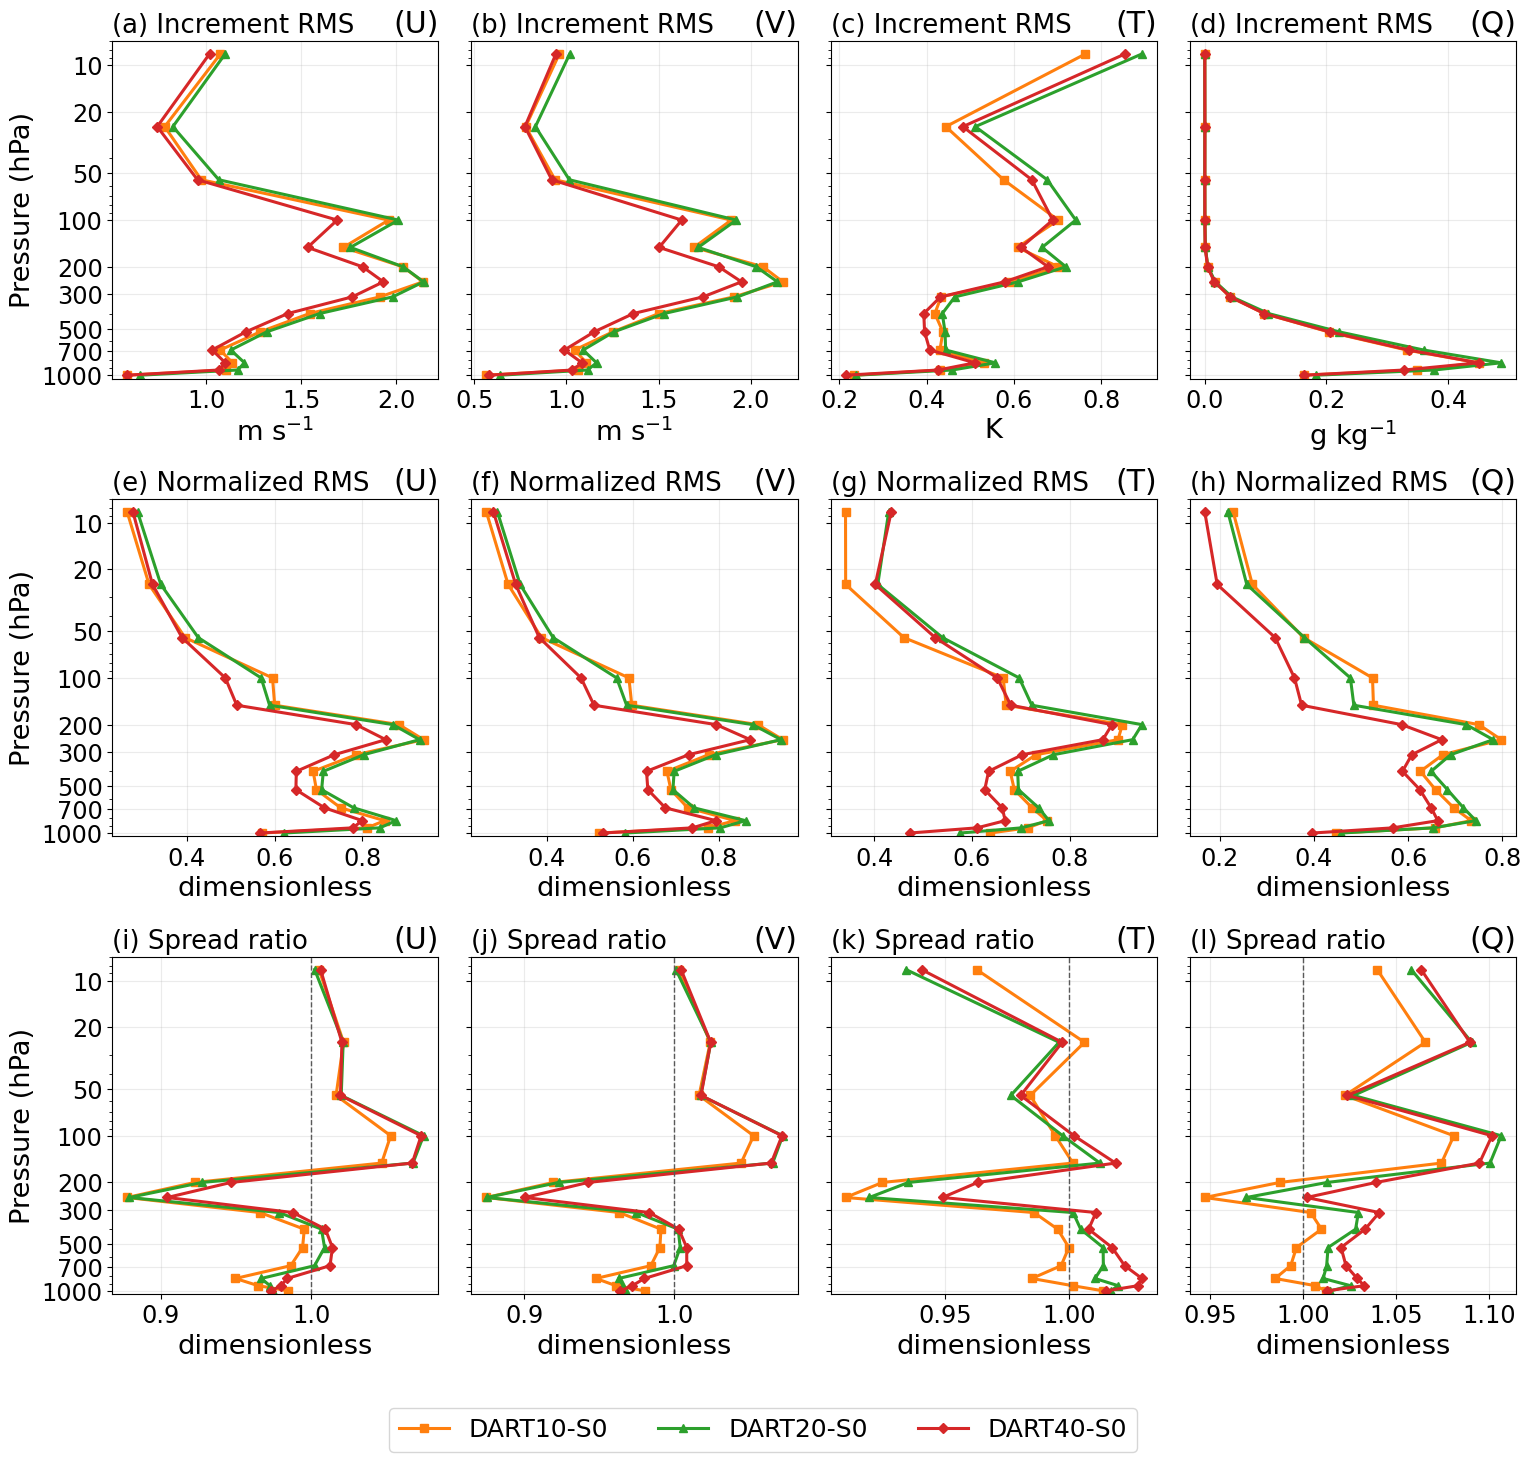

In [13]:
state_space_figures = {}
for window_name in PLOT_WINDOWS:
    experiments = FIGURE_REQUESTS[window_name]
    required_keys = {(window_name, experiment) for experiment in experiments}
    if required_keys.issubset(processed_profiles):
        state_space_figures[window_name] = plot_state_space_profiles(
            processed_profiles,
            window_name=window_name,
            experiments=experiments,
            show=SHOW or (SHOW_DEFAULT and window_name == DISPLAY_WINDOW),
            save=SAVE,
        )
    else:
        missing = sorted(required_keys.difference(processed_profiles))
        print(
            f"Figure for {window_name} not generated; missing caches: {missing}. "
            "Set RUN_FULL_WORKFLOW=True to build them."
        )


## Interpretation and follow-up

- The source variables are stored on EAM hybrid levels. Prior and posterior physical pressures are calculated separately from `hyam`, `hybm`, `P0`, and their respective `PS`, then interpolated to the common pressure-bin midpoints; the plotted markers therefore are not native model-level indices.
- The spread profiles are interpolated from stored hybrid-level DART ensemble SD. They are efficient summary-product diagnostics, but are not mathematically identical to interpolating every member first and then calculating pressure-level SD.
- Check `pressure_sd_validation` and `coverage_diagnostics`, especially 999 hPa, 8.5 hPa, and upper-level Q. A common inter-experiment spatial mask is needed if the reported S0 coverage differences exceed the configured tolerance.
- `rms_increment` measures the typical physical state correction.
- `rms_normalized_increment` measures correction magnitude relative to represented prior uncertainty; it has no universal ideal reference value.
- `spread_ratio < 1` indicates ensemble contraction during assimilation.
- `mean_increment` is retained in the cache to diagnose coherent signed corrections.
- `corr_abs_increment_prior_spread` is retained as a secondary diagnostic of whether larger corrections occur where the prior ensemble represents larger uncertainty.
- `07_state_update_spatial_patterns.ipynb` is a one-day spatial case-study companion to these profiles. It maps representative increments and posterior/prior spread ratios rather than repeating the long-window aggregate figure.
- The S1 profile window covers 17–31 May 2012, whereas the prior-innovation products in notebook 05 cover the full May period; compare S1 results qualitatively unless the windows are aligned.
- S0 uses the exact inclusive common-observation diagnostic window, 16 December 2011 00 UTC through 1 January 2012 00 UTC (65 six-hourly cycles). S1 retains its separately configured 17–31 May 2012 window.
- Set `RUN_WINDOW_SENSITIVITY=True` to process the 10- and 20-day S0 windows and inspect `window_sensitivity`; these checks do not create additional manuscript figures.
- DART40-S1 is plotted separately as an independent seasonal confirmation rather than mixed into the primary S0 ensemble-size panel.
- Adaptive-inflation fields are deliberately left for a later secondary/appendix analysis.
